In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [16]:
#Load Dataset
df = pd.read_csv("AmesHousing.csv")
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


# Part 1: Data Exploration

In [17]:
#1. Number of rows and columns
print("Shape of dataset (rows, columns):", df.shape)

Shape of dataset (rows, columns): (2930, 82)


In [18]:
# Column names and data types
print("\n Column Names and Data Types:")
print(df.dtypes)


 Column Names and Data Types:
Order               int64
PID                 int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 82, dtype: object


In [19]:
# Summary statistics for numeric features
print("\n Summary statistics for Numeric Features:")
print(df.describe())


 Summary statistics for Numeric Features:
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026    

In [20]:
# Count of missing values in each column
print("\n Missing Values per Column:")
print(df.isnull().sum())


 Missing Values per Column:
Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64


### Show some visualization about the dataset

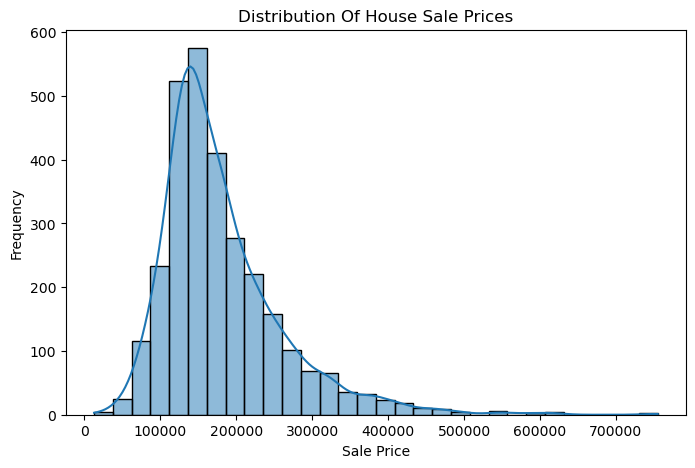

In [21]:
# Distribution of target variable (SalePrice)
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title("Distribution Of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

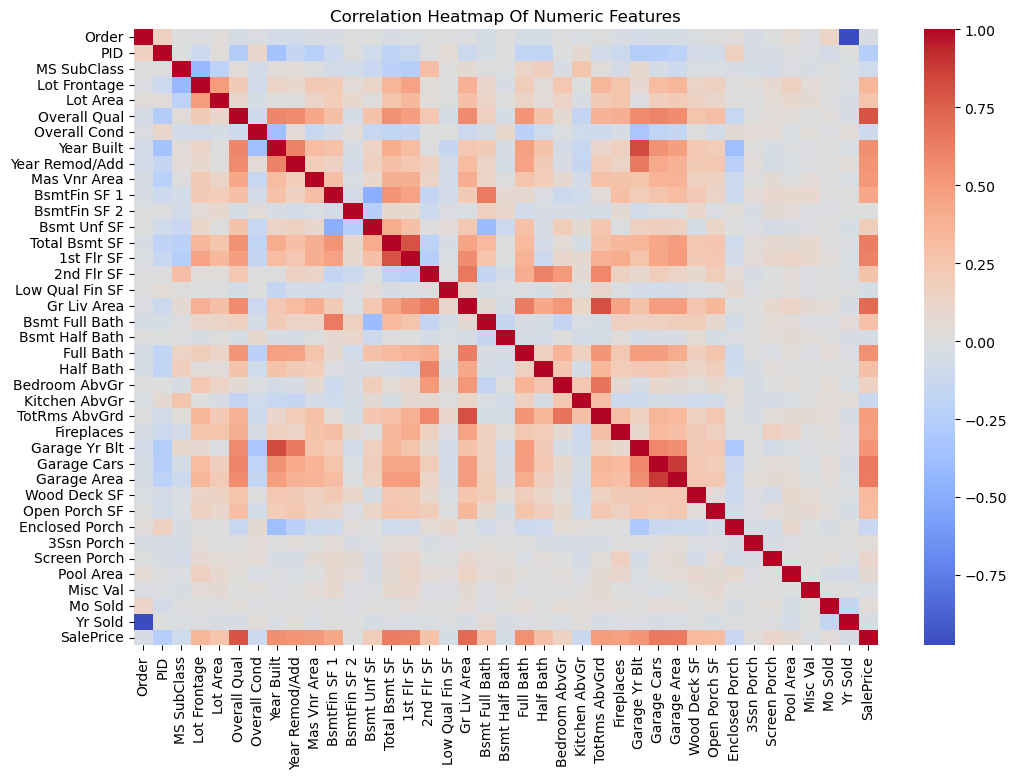

In [22]:
# Correlation heatmap of numeric variables
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap Of Numeric Features")
plt.show()

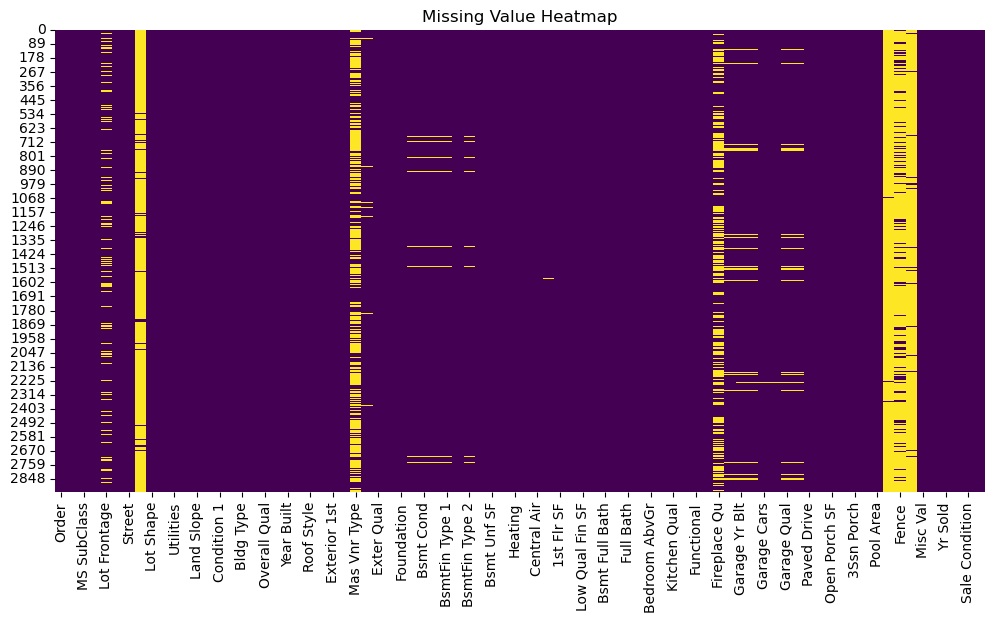

In [23]:
# Missing Values Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

# Part 2: Data Cleaning

## 1. Duplicate Records

In [25]:
# Identify duplicate rows
dup_mask = df.duplicated(keep="first")
num_dups = dup_mask.sum()
print(f"Duplicate rows found: {num_dups}")

df_nodup = df.drop_duplicates(keep="first").copy()
print(f"Shape after dropping duplicates: {df_nodup.shape} (removed {num_dups})")

Duplicate rows found: 0
Shape after dropping duplicates: (2930, 82) (removed 0)


In [30]:
# Invalid / Inconsistent Categorical Values

import pandas as pd
import numpy as np   
import re

def normalize_whitespace(s: pd.Series) -> pd.Series:
    # strip & collapse internal whitespace
    return s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

YES_TOKENS = {"y", "yes", "true", "t", "1"}
NO_TOKENS  = {"n", "no", "false", "f", "0"}
NONE_TOKENS = {"", "none", "n/a", "na", "null", "nil", "missing"}

def is_code_like(values, threshold=0.8):
    """
    Decide if a categorical column looks like code labels (e.g., 'RL','RM','TA').
    If >= threshold of unique non-null values are <=4 chars and all-uppercase letters/digits -> treat as code-like.
    """
    uniq = [v for v in values if pd.notna(v)]
    if not uniq:
        return False
    hits = 0
    for v in uniq:
        v_str = str(v)
        if len(v_str) <= 4 and v_str.upper() == v_str and re.fullmatch(r"[A-Z0-9() /.-]+", v_str or ""):
            hits += 1
    return hits / max(len(uniq), 1) >= threshold

def standardize_category_series(s: pd.Series) -> pd.Series:
    # normalize whitespace first
    s_clean = normalize_whitespace(s)

    # map common yes/no tokens
    lower = s_clean.str.lower()
    s_clean = np.where(lower.isin(YES_TOKENS), "Yes",
              np.where(lower.isin(NO_TOKENS), "No", s_clean))

    # convert explicit none-like tokens to NaN (we'll impute in Part 3)
    lower = pd.Series(s_clean).str.lower()
    s_clean = pd.Series(np.where(lower.isin(NONE_TOKENS), np.nan, s_clean), index=s.index)

    # decide casing strategy
    # gather current unique (excluding NaN) for heuristic
    uniques = pd.Series(s_clean).dropna().unique().tolist()
    if is_code_like(uniques):
        # code-like -> UPPER
        s_final = pd.Series(s_clean).str.upper()
    else:
        # descriptive -> Title Case (preserve parentheses spacing)
        s_final = pd.Series(s_clean).str.title()

    return s_final

def profile_inconsistencies_before(s: pd.Series, topn=20):
    """Return a quick profile of unique values ignoring case/space to surface near-duplicates."""
    tmp = s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    key = tmp.str.lower()
    grp = pd.DataFrame({"orig": tmp, "key": key}).groupby("key")["orig"].agg(lambda x: sorted(x.unique()))
    # show only keys that map to multiple different originals
    multi = grp[grp.apply(lambda lst: len(lst) > 1)]
    return multi.head(topn)

cat_cols = df_nodup.select_dtypes(include="object").columns.tolist()
print(f"\nDetected categorical columns: {len(cat_cols)}")

standardization_report = []

df_clean = df_nodup.copy()
for col in cat_cols:
    before_unique = df_clean[col].nunique(dropna=False)

    # capture potential inconsistencies prior to standardization
    inconsist = profile_inconsistencies_before(df_clean[col])
    if not inconsist.empty:
        print(f"\n[Potential inconsistencies before standardization] {col}")
        print(inconsist)

    col_before = df_clean[col].copy()
    df_clean[col] = standardize_category_series(df_clean[col])
    after_unique = df_clean[col].nunique(dropna=False)

    # Build a small mapping sample of changed values
    sample_changes = (
        pd.DataFrame({"before": col_before, "after": df_clean[col]})
        .dropna()
        .query("before != after")
        .drop_duplicates()
        .head(8)
        .values.tolist()
    )
    standardization_report.append({
        "column": col,
        "unique_before": before_unique,
        "unique_after": after_unique,
        "example_changes": sample_changes
    })


Detected categorical columns: 43


In [31]:
# Report
changed_cols = [r for r in standardization_report if r["unique_before"] != r["unique_after"] or r["example_changes"]]
print("\n=== Standardization Summary (only columns with changes shown) ===")
for r in changed_cols:
    print(f"- {r['column']}: unique {r['unique_before']} -> {r['unique_after']}")
    if r["example_changes"]:
        for b, a in r["example_changes"]:
            print(f"    '{b}'  =>  '{a}'")


=== Standardization Summary (only columns with changes shown) ===
- MS Zoning: unique 7 -> 7
    'RL'  =>  'Rl'
    'RH'  =>  'Rh'
    'FV'  =>  'Fv'
    'RM'  =>  'Rm'
    'C (all)'  =>  'C (All)'
    'I (all)'  =>  'I (All)'
    'A (agr)'  =>  'A (Agr)'
- Lot Shape: unique 4 -> 4
    'IR1'  =>  'Ir1'
    'IR2'  =>  'Ir2'
    'IR3'  =>  'Ir3'
- Land Contour: unique 4 -> 4
    'HLS'  =>  'Hls'
- Utilities: unique 3 -> 3
    'AllPub'  =>  'Allpub'
    'NoSewr'  =>  'Nosewr'
    'NoSeWa'  =>  'Nosewa'
- Lot Config: unique 5 -> 5
    'CulDSac'  =>  'Culdsac'
    'FR2'  =>  'Fr2'
    'FR3'  =>  'Fr3'
- Neighborhood: unique 28 -> 28
    'NAmes'  =>  'Names'
    'StoneBr'  =>  'Stonebr'
    'NWAmes'  =>  'Nwames'
    'BrDale'  =>  'Brdale'
    'NPkVill'  =>  'Npkvill'
    'NridgHt'  =>  'Nridght'
    'NoRidge'  =>  'Noridge'
    'SawyerW'  =>  'Sawyerw'
- Condition 1: unique 9 -> 9
    'PosN'  =>  'Posn'
    'RRNe'  =>  'Rrne'
    'RRAe'  =>  'Rrae'
    'PosA'  =>  'Posa'
    'RRAn'  =>  'R

In [32]:
# Save the cleaned dataset
out_path = "AmesHousing_clean_step2.csv"
df_clean.to_csv(out_path, index=False)
print(f"\nSaved cleaned (step 2) dataset to: {out_path}")
print(f"Final shape after Part 2: {df_clean.shape}")


Saved cleaned (step 2) dataset to: AmesHousing_clean_step2.csv
Final shape after Part 2: (2930, 82)


## 2. Invalid / Inconsistent Values

In [33]:
# Find categorical columns with typos or inconsistent values (e.g., "male", "Male", "M")
import pandas as pd
import numpy as np
import re

df = pd.read_csv("AmesHousing_clean_step2.csv")
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 2930 rows, 82 columns


In [34]:
# ---------- Helpers ----------

YES_TOKENS = {"y", "yes", "true", "t", "1"}
NO_TOKENS  = {"n", "no", "false", "f", "0"}
NONE_TOKENS = {"", "none", "n/a", "na", "null", "nil", "missing", "nan"}

def normalize_whitespace(s: pd.Series) -> pd.Series:
    """Strip and collapse internal whitespace."""
    return s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

def is_code_like(values, threshold=0.8):
    """
    Heuristic: treat as code labels (e.g., 'RL','RM','TA','Ex') when most values
    are short (<=4 chars) and all-uppercase alphanumerics/symbols.
    """
    uniq = [v for v in values if pd.notna(v)]
    if not uniq:
        return False
    hits = 0
    for v in uniq:
        v_str = str(v)
        if len(v_str) <= 4 and v_str.upper() == v_str and re.fullmatch(r"[A-Z0-9() /.\-]+", v_str or ""):
            hits += 1
    return hits / max(len(uniq), 1) >= threshold

def standardize_yes_no(series: pd.Series) -> pd.Series:
    """Map common yes/no variants to Yes/No; leave others unchanged."""
    lower = series.str.lower()
    mapped = np.where(lower.isin(YES_TOKENS), "Yes",
             np.where(lower.isin(NO_TOKENS), "No", series))
    return pd.Series(mapped, index=series.index)

def to_missing(series: pd.Series) -> pd.Series:
    """Convert explicit none-like tokens to NaN (impute in Part 3)."""
    lower = series.str.lower()
    return pd.Series(np.where(lower.isin(NONE_TOKENS), np.nan, series), index=series.index)

def profile_inconsistencies(series: pd.Series, topn=15) -> pd.DataFrame:
    """
    Show groups where multiple raw spellings map to the same lowercased key.
    Useful to spot typos like ['male','Male',' M '].
    """
    tmp = series.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    key = tmp.str.lower()
    grp = pd.DataFrame({"orig": tmp, "key": key}).groupby("key")["orig"].agg(lambda x: sorted(x.unique()))
    return grp[grp.apply(lambda lst: len(lst) > 1)].head(topn)

# Column-specific synonym maps (extend as needed)
# Example shows a 'Gender' column even if Ames doesn't have it—pattern is reusable.
COLUMN_SYNONYM_MAPS = {
    # "Gender": {"Male": ["m","male","MALE","M"], "Female": ["f","female","FEMALE","F"]},
    # "Smoker": {"Yes": ["y","yes","true","1"], "No": ["n","no","false","0"]},
}

# Ames-specific helpful maps (applied only if those columns exist)
if "CentralAir" in df.columns:
    COLUMN_SYNONYM_MAPS["CentralAir"] = {"Yes": ["y","Y","yes"], "No": ["n","N","no"]}
if "Street" in df.columns:
    COLUMN_SYNONYM_MAPS["Street"] = {"Pave": ["pave","paved","PAVED"], "Grvl": ["gravel","grvl","GRAVEL"]}
if "Alley" in df.columns:
    COLUMN_SYNONYM_MAPS["Alley"] = {"Grvl": ["grvl","gravel"], "Pave": ["pave","paved"]}

def apply_synonym_map(series: pd.Series, syn_map: dict) -> pd.Series:
    """Apply a {Canonical: [variants]} map to a series (case-insensitive)."""
    if not syn_map:
        return series
    # Build reverse lookup
    rev = {}
    for canon, variants in syn_map.items():
        rev[canon.lower()] = canon
        for v in variants:
            rev[str(v).lower()] = canon
    return series.apply(lambda x: rev.get(str(x).lower(), x))

def standardize_categorical(series: pd.Series, colname: str) -> pd.Series:
    s = normalize_whitespace(series)

    # Column-specific synonyms first (if declared)
    if colname in COLUMN_SYNONYM_MAPS:
        s = apply_synonym_map(s, COLUMN_SYNONYM_MAPS[colname])

    # Generic Yes/No normalization
    s = standardize_yes_no(s)

    # Convert explicit "none-ish" tokens to NaN
    s = to_missing(s)

    # Decide case style by heuristic
    uniques = pd.Series(s).dropna().unique().tolist()
    if is_code_like(uniques):
        s = pd.Series(s).str.upper()
    else:
        s = pd.Series(s).str.title()  # e.g., "c (all)" -> "C (All)"
    return s


In [35]:
# ---------- Run standardization ----------

cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns detected: {len(cat_cols)}")

report = []
df_std = df.copy()

for col in cat_cols:
    # Show potential inconsistencies before fixing
    inc = profile_inconsistencies(df_std[col])
    if not inc.empty:
        print(f"\n[Inconsistencies BEFORE] {col}")
        print(inc)

    before_unique = df_std[col].nunique(dropna=False)
    col_before = df_std[col].copy()

    df_std[col] = standardize_categorical(df_std[col], col)

    after_unique = df_std[col].nunique(dropna=False)

    # Show a few example mappings that actually changed
    examples = (
        pd.DataFrame({"before": col_before, "after": df_std[col]})
        .dropna()
        .query("before != after")
        .drop_duplicates()
        .head(10)
        .values.tolist()
    )

    report.append({
        "column": col,
        "unique_before": before_unique,
        "unique_after": after_unique,
        "examples": examples
    })

print("\n=== Standardization Summary (only changed columns) ===")
for r in report:
    if r["unique_before"] != r["unique_after"] or len(r["examples"]) > 0:
        print(f"- {r['column']}: unique {r['unique_before']} -> {r['unique_after']}")
        for b, a in r["examples"]:
            print(f"    '{b}'  =>  '{a}'")

# Save output (no imputation here; handle missingness in Part 3)
out_path = "AmesHousing_categoricals_standardized.csv"
df_std.to_csv(out_path, index=False)
print(f"\nSaved standardized dataset to: {out_path}")

Categorical columns detected: 43

=== Standardization Summary (only changed columns) ===

Saved standardized dataset to: AmesHousing_categoricals_standardized.csv


# Part 3: Missing Data Handling

## Identify Missing Data

In [36]:
# Create a table showing percentage of missing values per column
df = pd.read_csv("AmesHousing_clean_step2.csv")
# 1. Table: % missing values per column
missing_table = (
    df.isnull().sum()
    .to_frame("MissingCount")
    .assign(MissingPct=lambda x: (x["MissingCount"] / len(df)) * 100)
    .sort_values("MissingPct", ascending=False)
)

print("\n=== Missing Data Table ===")
print(missing_table.head(15))   # show top 15 columns with most missing



=== Missing Data Table ===
                MissingCount  MissingPct
Lot Frontage             490   16.723549
Garage Yr Blt            159    5.426621
Mas Vnr Area              23    0.784983
Bsmt Full Bath             2    0.068259
Bsmt Half Bath             2    0.068259
Garage Cars                1    0.034130
Total Bsmt SF              1    0.034130
Bsmt Unf SF                1    0.034130
BsmtFin SF 2               1    0.034130
BsmtFin SF 1               1    0.034130
Garage Area                1    0.034130
TotRms AbvGrd              0    0.000000
Fireplace Qu               0    0.000000
Fireplaces                 0    0.000000
Functional                 0    0.000000


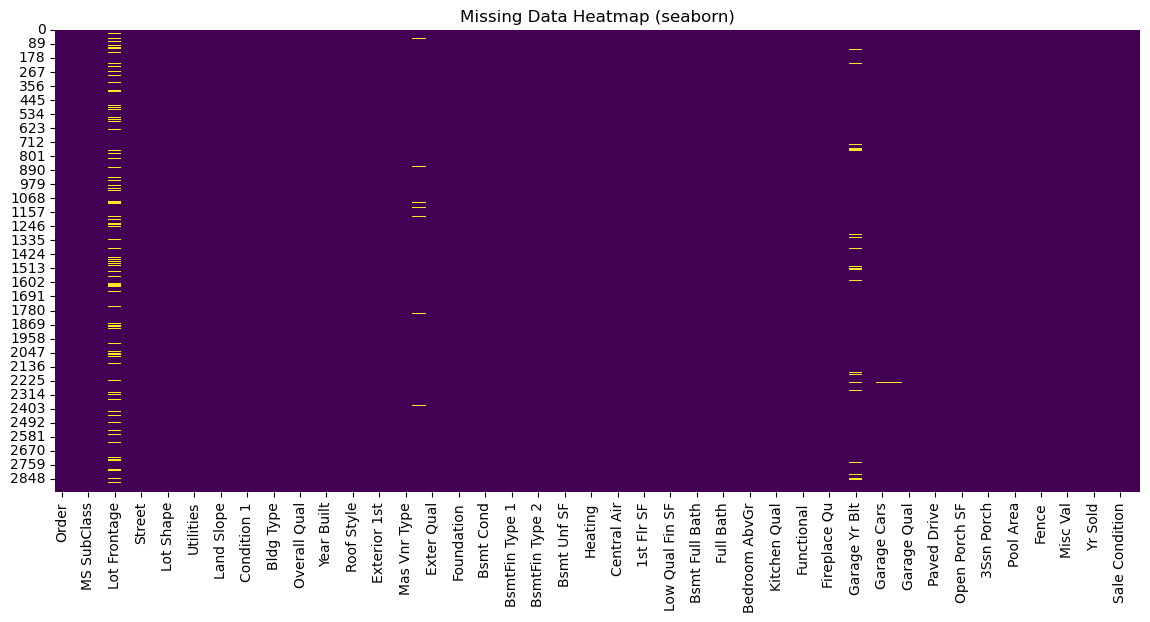

In [37]:
# 2. Visualize missingness with seaborn heatmap
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap (seaborn)")
plt.show()

## Handle Missing Numerical Features

In [39]:
# Replace missing values using mean, median, or interpolation (justify your choice)
df = pd.read_csv("AmesHousing_clean_step2.csv")

# Identify numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns


Numerical features with missing values:
Lot Frontage      490
Mas Vnr Area       23
BsmtFin SF 1        1
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Bsmt Full Bath      2
Bsmt Half Bath      2
Garage Yr Blt     159
Garage Cars         1
Garage Area         1
dtype: int64
Filled Lot Frontage missing values with median: 68.0
Filled Mas Vnr Area missing values with median: 0.0
Filled BsmtFin SF 1 missing values with median: 370.0
Filled BsmtFin SF 2 missing values with median: 0.0
Filled Bsmt Unf SF missing values with median: 466.0
Filled Total Bsmt SF missing values with median: 990.0
Filled Bsmt Full Bath missing values with median: 0.0
Filled Bsmt Half Bath missing values with median: 0.0
Filled Garage Yr Blt missing values with median: 1979.0
Filled Garage Cars missing values with median: 2.0
Filled Garage Area missing values with median: 480.0

After imputation, numerical missing counts:
0 missing values remain.


/var/folders/jq/0xcl_s1d1xs3cvnq58y_86r00000gn/T/ipykernel_19555/1718539879.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


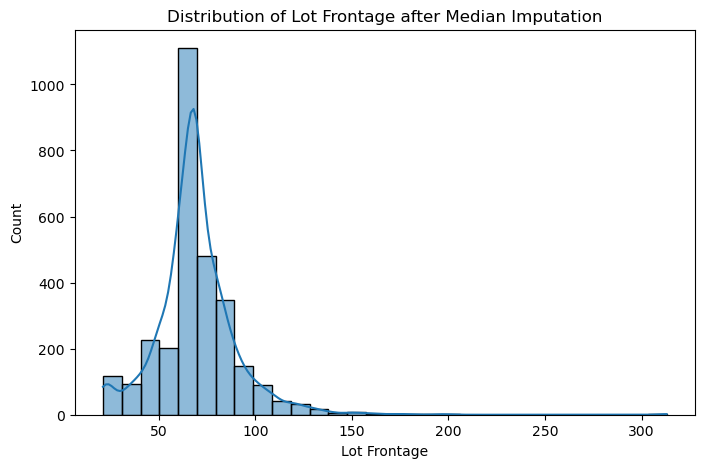


Saved dataset after numerical imputation -> AmesHousing_clean_step3_num.csv


In [40]:
# Check missing values in numerical columns
num_missing = df[num_cols].isnull().sum()
print("\nNumerical features with missing values:")
print(num_missing[num_missing > 0])

# ---- Strategy: Fill with MEDIAN (robust to skew) ----
for col in num_missing[num_missing > 0].index:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Filled {col} missing values with median: {median_val}")

# Verify
print("\nAfter imputation, numerical missing counts:")
print(df[num_cols].isnull().sum().sum(), "missing values remain.")

# Optional visualization: Example before/after distribution for a key column
col_example = "Lot Frontage"  # change to any column with missing values
plt.figure(figsize=(8,5))
sns.histplot(df[col_example], kde=True, bins=30)
plt.title(f"Distribution of {col_example} after Median Imputation")
plt.show()

# Save intermediate cleaned dataset
df.to_csv("AmesHousing_clean_step3_num.csv", index=False)
print("\nSaved dataset after numerical imputation -> AmesHousing_clean_step3_num.csv")

In [41]:
df = pd.read_csv("AmesHousing_clean_step3_num.csv")

# Identify categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Check missing values in categorical columns
cat_missing = df[cat_cols].isnull().sum()
print("\nCategorical features with missing values:")
print(cat_missing[cat_missing > 0])



Categorical features with missing values:
Series([], dtype: int64)


In [42]:
# ---- Strategy ----
# 1. For 'Alley','Fence','MiscFeature','PoolQC','FireplaceQu','GarageType', etc. -> 'Unknown'
# 2. Otherwise, fill with Mode (most frequent value)

special_unknown = ["Alley", "Fence", "MiscFeature", "PoolQC", "Fireplace Qu", 
                   "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond"]

for col in cat_missing[cat_missing > 0].index:
    if col in special_unknown:
        df[col].fillna("Unknown", inplace=True)
        print(f"Filled {col} missing values with 'Unknown'")
    else:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled {col} missing values with mode: {mode_val}")

# Verify
print("\nAfter imputation, categorical missing counts:")
print(df[cat_cols].isnull().sum().sum(), "missing values remain.")

# Save final cleaned dataset
df.to_csv("AmesHousing_clean_step3_full.csv", index=False)
print("\nSaved dataset after categorical imputation -> AmesHousing_clean_step3_full.csv")


After imputation, categorical missing counts:
0 missing values remain.

Saved dataset after categorical imputation -> AmesHousing_clean_step3_full.csv


In [44]:
from sklearn.impute import KNNImputer

# Load dataset before missing handling (step 2)
df = pd.read_csv("AmesHousing_clean_step2.csv")

# Identify numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Apply KNN imputer only on numeric features
imputer = KNNImputer(n_neighbors=5)  # you can tune n_neighbors
df_num_imputed = pd.DataFrame(
    imputer.fit_transform(df[num_cols]),
    columns=num_cols
)

# Replace numeric columns with imputed values
df[num_cols] = df_num_imputed

# Verify no missing in numeric columns
print("\nMissing values after KNN imputation (numeric only):")
print(df[num_cols].isnull().sum().sum(), "missing values remain.")


Missing values after KNN imputation (numeric only):
0 missing values remain.


In [45]:
# Save the KNN-imputed dataset
df.to_csv("AmesHousing_clean_step3_knn.csv", index=False)
print("\nSaved KNN-imputed dataset -> AmesHousing_clean_step3_knn.csv")


Saved KNN-imputed dataset -> AmesHousing_clean_step3_knn.csv


# Part 4: Verification

In [46]:
# Load before-cleaning dataset (raw)
df_raw = pd.read_csv("AmesHousing.csv")

# Load after-cleaning dataset (fully processed in Part 3)
df_clean = pd.read_csv("AmesHousing_clean_step3_full.csv")

# 1. Show shapes before vs after cleaning
print("=== Dataset Shape ===")
print(f"Before cleaning: {df_raw.shape}")
print(f"After cleaning:  {df_clean.shape}")

# 2. Confirm no missing values remain
print("\n=== Missing Values Check ===")
print("Before cleaning (total missing):", df_raw.isnull().sum().sum())
print("After cleaning (total missing): ", df_clean.isnull().sum().sum())

# 3. Spot check a few columns before vs after
cols_to_check = ["Lot Frontage", "Alley", "MS Zoning", "SalePrice"]  # sample
for col in cols_to_check:
    if col in df_raw.columns:
        print(f"\n--- {col} ---")
        print("Before (missing):", df_raw[col].isnull().sum())
        print("After  (missing):", df_clean[col].isnull().sum())


=== Dataset Shape ===
Before cleaning: (2930, 82)
After cleaning:  (2930, 82)

=== Missing Values Check ===
Before cleaning (total missing): 15749
After cleaning (total missing):  0

--- Lot Frontage ---
Before (missing): 490
After  (missing): 0

--- Alley ---
Before (missing): 2732
After  (missing): 0

--- MS Zoning ---
Before (missing): 0
After  (missing): 0

--- SalePrice ---
Before (missing): 0
After  (missing): 0


## Discussion 

- Duplicates removed: Prevents bias from repeated records (e.g., same house counted twice).
- Categorical standardization: Ensures model treats "RL" and "rl" as the same, avoiding artificial class splits.
- Numerical imputation (median): Preserves distribution better than mean, especially with skewed housing data.
- Categorical imputation (mode/Unknown): Retains meaningful structure (e.g., "Unknown" for Alley captures absence).
- KNN : Improves numerical imputations by using neighborhood patterns, though it increases computation.